## Introducción

MiDaS v3.1 es una familia de modelos de estimación de profundidad relativa que produce mapas de profundidad densos a partir de una sola imagen RGB. Está diseñado para proporcionar predicciones robustas y comparables entre distintas escenas — no entrega profundidad absoluta en metros, sino una representación relativa que conserva la estructura geométrica. MiDaS se ha usado ampliamente como etapa previa para reconstrucción 3D, segmentación por profundidad y tareas que requieren información de orden relativo en la escena.

## Repositorio

Repositorio oficial: https://github.com/isl-org/MiDaS

Resumen rápido de uso:
- Código principal y scripts de inferencia (por ejemplo `run.py`) en el repositorio.
- Modelos preentrenados disponibles en la sección de releases (p. ej. `dpt_beit_large_512`, `dpt_swin2_large_384`, etc.).
- Se recomienda crear un entorno (conda o pip) usando el `environment.yaml` o instalar dependencias listadas en el README antes de ejecutar los scripts.
- Ejemplo de ejecución (desde la carpeta del repo):
  - `python run.py --model_type dpt_beit_large_512 --input_path INPUT_DIR --output_path OUTPUT_DIR`

## Arquitectura

- Backbones principales:
  - DPT (Dense Prediction Transformer) con variantes como BEiT y Swin: utilizan transformadores como extractor de características para mejorar la resolución y la coherencia estructural en la predicción de profundidad.
  - Modelos más ligeros y más grandes están disponibles (p. ej. `dpt_swin2_large_384` para mayor calidad, `dpt_beit_large_512` para un buen equilibrio).
- Salida:
  - Mapas de profundidad relativos por píxel (matrices flotantes). No representan distancia absoluta, sino escala relativa dentro de cada imagen.
  - Usualmente se guarda un mapa normalizado (p. ej. PNG o .npy) y/o una visualización en falso color para inspección.
- Preprocesado / Postprocesado:
  - Entrada: imágenes RGB, dimensionadas al tamaño requerido por el modelo (los scripts del repo manejan el reescalado y normalización).
  - Post-procesado típico: normalización del mapa de profundidad, aplicación de colormap para visualización y, si se requiere, conversión a formato numpy (.npy) para uso posterior.
- Requisitos:
  - Peso de modelos grandes (varios cientos de MB a varios GB). Añadir `MiDaS/weights/` a `.gitignore` para evitar commitear pesos.
  - GPU recomendada para inferencia razonable; PyTorch compatible con la versión de CUDA del sistema (en tu caso usar wheel cu121 para CUDA 12.3/12.x como ya configuraste).
- Casos de uso:
  - Ordenamiento de escena (near/far), entrada previa para reconstrucción 3D, segmentación por profundidad y análisis de geometría en imágenes monoculares.

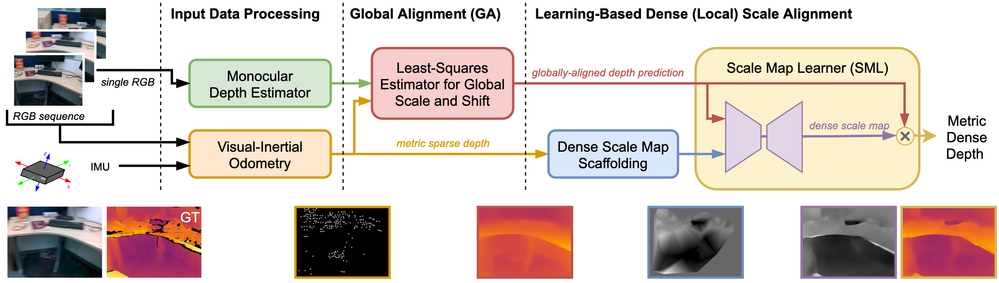

In [1]:
# Instalación de dependencias principales para MiDaS v3.1
%pip install torch==2.4.0 torchvision==0.19.0 --index-url https://download.pytorch.org/whl/cu121
%pip install timm opencv-python matplotlib numpy tqdm scipy
%pip install imutils

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Imports principales para MiDaS v3.1
import torch
import timm
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy

c:\Users\VICTUS hp\Desktop\IA PACHECO\IC_MMP\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Descarga y carga del modelo MiDaS v3.1 (dpt_beit_large_512)
import os
import urllib.request

# Carpeta donde se guardarán los pesos
dest_weights = "weights/dpt_beit_large_512.pt"
os.makedirs("weights", exist_ok=True)

# Enlace oficial de los pesos (release de MiDaS)
weights_url = "https://github.com/isl-org/MiDaS/releases/download/v3_1/dpt_beit_large_512.pt"
if not os.path.exists(dest_weights):
    print("Descargando pesos del modelo...")
    urllib.request.urlretrieve(weights_url, dest_weights)
    print("Pesos descargados en:", dest_weights)
else:
    print("Pesos ya existen en:", dest_weights)

Pesos ya existen en: weights/dpt_beit_large_512.pt


Initialize
Device: cuda
Model loaded, number of parameters = 345M
Start processing
  Processing c:\Users\VICTUS hp\Desktop\IA PACHECO\IC_MMP\MiDaS v3.1\assets\examples\basura01.jpg (1/2)
    Input resized to 512x256 before entering the encoder
  Processing c:\Users\VICTUS hp\Desktop\IA PACHECO\IC_MMP\MiDaS v3.1\assets\examples\basura02.jpg (2/2)
    Input resized to 928x512 before entering the encoder
Finished

C:\Users\VICTUS hp\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\VICTUS hp\Desktop\IA PACHECO\IC_MMP\MiDaS v3.1\MiDaS\midas\base_model.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default 

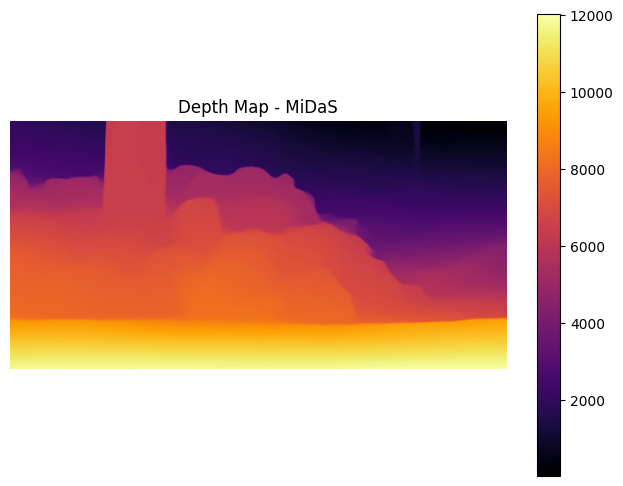

In [12]:
import subprocess
import os
import cv2
import matplotlib.pyplot as plt

input_path = os.path.abspath("assets/examples")
output_path = os.path.abspath("assets/results")
weights_path = os.path.abspath("weights/dpt_beit_large_512.pt")

model_type = "dpt_beit_large_512"

os.makedirs(output_path, exist_ok=True)

cmd = [
    "python", "MiDaS/run.py",
    "--model_type", model_type,
    "--input_path", input_path,
    "--output_path", output_path,
    "--model_weights", weights_path
]

result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)
print(result.stderr)

files = os.listdir(output_path)
print("Resultados generados:", files)

if files:
    depth_path = os.path.join(output_path, files[0])

    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

    plt.figure(figsize=(8,6))
    plt.imshow(depth, cmap="inferno")
    plt.title("Depth Map - MiDaS")
    plt.axis("off")
    plt.colorbar()
    plt.show()